# 1) Veri klasörünü indiriniz.

In [ ]:
# import gdown

# # Dosya ID'si ve hedef dosya adı
# file_id = "1JYnUVcI32NpDMjZ3PWMUcJJ6wWaJVw-e"
# output_file = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi.rar"
# extract_folder = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi"

# # Google Drive'dan dosyayı indir
# gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

In [ ]:
!pip install rarfile -q
import rarfile
import os

output_file = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi.rar"
extract_folder = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi_yeni"

# RAR dosyasını çıkart
if not os.path.exists(extract_folder):
    os.makedirs(extract_folder)

with rarfile.RarFile(output_file) as rf:
    rf.extractall(extract_folder)

print(f"Dosya '{output_file}' indirildi ve '{extract_folder}' klasörüne çıkarıldı.")

Dosya '/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi.rar' indirildi ve '/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi_yeni' klasörüne çıkarıldı.


In [ ]:
import os

mask_folder = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi_yeni/masks"
images_folder = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi_yeni/images"

mask_count = 0
if os.path.exists(mask_folder):
  mask_count = len([f for f in os.listdir(mask_folder) if os.path.isfile(os.path.join(mask_folder, f))])

images_count = 0
if os.path.exists(images_folder):
  images_count = len([f for f in os.listdir(images_folder) if os.path.isfile(os.path.join(images_folder, f))])

print(f"Mask klasöründeki resim sayısı: {mask_count}")
print(f"Images klasöründeki resim sayısı: {images_count}")


Mask klasöründeki resim sayısı: 2383
Images klasöründeki resim sayısı: 2383


# 2) Beyin bölgesinin haricindeki kısımlara 0 değerini atayarak dosyaları güncelleyiniz.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Beyin segmentasyonu yapan ve segmentasyon bölgelerindeki boşlukları dolduran fonksiyon
def segment_brain_inside_skull(image_path, skull_threshold=254, brain_threshold=10, max_regions=3, min_region_size=1800):
    # Görüntüyü yükle
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Hata: {image_path} yüklenemedi!")
        return None, None, None, None, None, None

    # 1. Kafatası konturu belirleme
    # Önce görüntüyü yumuşatma
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Kafatasının yüksek yoğunluklu bölgelerini tespit et
    _, skull_thresh = cv2.threshold(blurred, skull_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle kafatasını kalınlaştır
    kernel = np.ones((5, 5), np.uint8)
    skull_dilated = cv2.dilate(skull_thresh, kernel, iterations=2)

    # 2. Kafatası konturunun içini doldur (kafatası boşluğunu elde et)
    # Önce büyük bir kontur elde etmek için morfolojik işlemlerle kapatma
    skull_closed = cv2.morphologyEx(skull_dilated, cv2.MORPH_CLOSE, kernel, iterations=10)

    # Kafatası boşluğunu içerecek şekilde tüm konturları bul
    contours, _ = cv2.findContours(skull_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Kafatası konturu için boş bir maske oluştur
    skull_cavity_mask = np.zeros_like(image)

    # En büyük konturu kafatası olarak varsay ve içini doldur
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        # Convex Hull ile konturu tamamla
        hull = cv2.convexHull(largest_contour)
        cv2.drawContours(skull_cavity_mask, [hull], 0, 255, -1)

    # 3. Beyin bölgesini tespit et
    # Kafatası içindeki bölgelere odaklan (kafatası olmayan bölgeyi al)
    non_skull = cv2.bitwise_not(skull_dilated)

    # Kafatası boşluğu VE kafatası olmayan bölge = sadece kafatası içindeki yumuşak doku
    inner_region = cv2.bitwise_and(skull_cavity_mask, non_skull)

    # Beyin dokusunu diğer yumuşak dokulardan ayırmak için eşikleme
    _, brain_thresh = cv2.threshold(cv2.bitwise_and(blurred, blurred, mask=inner_region),
                                  brain_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle beyin bölgesini temizle
    brain_mask = cv2.morphologyEx(brain_thresh, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=2)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)

    # 4. Büyük bağlantılı beyin bölgelerini seç
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(brain_mask, connectivity=8)

    # Sadece yeterince büyük (min_region_size'dan büyük) bölgeleri filtrele
    filtered_regions = []
    for i in range(1, num_labels):  # 0 indeksi arka plan olduğu için atla
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_region_size:
            filtered_regions.append((i, area))

    # Alan bazında büyükten küçüğe sırala
    filtered_regions.sort(key=lambda x: x[1], reverse=True)

    # En fazla max_regions sayıda bölgeyi seç
    selected_regions = filtered_regions[:max_regions]

    # Seçilen bölgelerin maskelerini hazırla
    final_brain_mask = np.zeros_like(brain_mask)

    # Her bir seçilen bölgeyi ayrı ayrı işle
    for label, _ in selected_regions:
        # Bölgeyi maskele
        current_mask = (labels == label).astype(np.uint8) * 255

        # Bölgedeki boşlukları doldur
        # Konturları bul (dış kontur ve iç boşluklar)
        contours, hierarchy = cv2.findContours(current_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

        # Tüm konturları (dış kontur ve tüm iç boşluklar) doldur
        filled_mask = np.zeros_like(current_mask)
        for i, contour in enumerate(contours):
            # hierarchy[0, i, 3] == -1 ise bu dış kontur demektir
            # Tüm konturları doldurmak istediğimiz için bu kontrolü kullanmıyoruz
            cv2.drawContours(filled_mask, [contour], 0, 255, -1)

        # Doldurulmuş maske ile final maskeyi güncelle
        final_brain_mask = cv2.bitwise_or(final_brain_mask, filled_mask)

    # Boşlukları doldurulmuş maskeyi bir daha işleyelim
    # Alternatif bir yaklaşımla, morfolojik kapatma (closing) işlemi de uygulayalım
    final_brain_mask = cv2.morphologyEx(final_brain_mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)

    # Beyin bölgesini çıkar
    brain_only = cv2.bitwise_and(image, image, mask=final_brain_mask)

    # Görselleştirme için renkli sonuç hazırla
    colored_result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Renkli görselleştirmede her bölgeyi farklı renkle işaretle
    colors = [(0, 255, 0), (0, 255, 255), (255, 0, 255)]  # Yeşil, Sarı, Mor

    # Farklı renklerle segmentasyon görselleştirmesi için tekrar bağlantılı bileşen analizi yap
    # (boşluklar doldurulduktan sonra)
    num_labels_filled, labels_filled = cv2.connectedComponents(final_brain_mask)

    # Her bir seçilen bölge için farklı renk kullan
    for i, (original_label, _) in enumerate(selected_regions):
        if i < len(colors):
            # Doldurulmuş bölgelerdeki yeni etiketi bul
            # En çok örtüşen bölgeyi bul
            max_overlap = 0
            max_overlap_label = 0

            for j in range(1, num_labels_filled):
                # Orijinal maske
                original_mask = (labels == original_label)
                # Yeni maske
                new_mask = (labels_filled == j)
                # Örtüşen pikseller
                overlap = np.sum(np.logical_and(original_mask, new_mask))

                if overlap > max_overlap:
                    max_overlap = overlap
                    max_overlap_label = j

            # En çok örtüşen bölgeyi renklendir
            if max_overlap_label > 0:
                region_mask = (labels_filled == max_overlap_label)
                colored_result[region_mask] = colors[i]

    # Kafatasını kırmızı olarak işaretle
    colored_result[skull_dilated > 0] = [0, 0, 255]

    # Hem seçilen bölgeleri hem de beyin bölgelerinin boyut sıralamasını döndür
    return image, skull_cavity_mask, final_brain_mask, brain_only, colored_result, selected_regions

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# Fonksiyon: Belirtilen klasördeki tüm görüntülere beyin segmentasyonu uygula ve kaydet
def process_brain_images(main_folder, class_folders=[0, 1]):
    total_processed = 0
    total_failed = 0

    for class_folder in class_folders:
        # Klasör yolu oluştur
        folder_path = os.path.join(main_folder, str(class_folder))

        # Klasördeki tüm jpg dosyalarını listele
        image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        print(f"\nİşleniyor: {folder_path} - Toplam {len(image_files)} dosya")

        # Tüm görüntüleri işle
        for image_file in tqdm(image_files):
            image_path = os.path.join(folder_path, image_file)

            # Beyin segmentasyonu yap
            results = segment_brain_inside_skull(
                image_path,
                skull_threshold=253,
                brain_threshold=30,
                max_regions=3,
                min_region_size=1800
            )

            if results is None or len(results) < 6:
                print(f"  Hata: {image_file} için segmentasyon başarısız!")
                total_failed += 1
                continue

            # Sadece beyin bölgesini al (brain_only)
            brain_only = results[3]

            # Orijinal dosya adıyla kaydet (üzerine yaz)
            cv2.imwrite(image_path, brain_only)
            total_processed += 1

    return total_processed, total_failed

# Ana kod: Tüm dataset'i işle
base_path = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/"

# İşlenecek klasörler
folders_to_process = [
    os.path.join(base_path, "BeyinInmeVerisi_yeni"),
]

# Her bir ana klasör için işleme yap
total_success = 0
total_errors = 0

for folder in folders_to_process:
    print(f"\n{folder} klasörü işleniyor...")
    success, errors = process_brain_images(folder, class_folders=["images"])
    total_success += success
    total_errors += errors

print(f"\nİşlem tamamlandı!")
print(f"Toplam başarıyla işlenen görüntü: {total_success}")
print(f"Toplam başarısız işlem: {total_errors}")


/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi_yeni klasörü işleniyor...

İşleniyor: /content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi_yeni/images - Toplam 2383 dosya


100%|██████████| 2383/2383 [01:22<00:00, 29.05it/s]


İşlem tamamlandı!
Toplam başarıyla işlenen görüntü: 2383
Toplam başarısız işlem: 0


# Kütüphaneleri import et

In [1]:
!pip install monai -q

!pip install --upgrade monai -q
!pip install --upgrade numpy -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
monai 1.4.0 requires numpy<2.0,>=1.24, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


In [2]:
import logging
import os
import sys
import tempfile
from glob import glob
import numpy as np
import cv2

import torch
from PIL import Image
from torch.utils.tensorboard import SummaryWriter

import monai
from monai.data import ArrayDataset, create_test_image_2d, decollate_batch, DataLoader
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.transforms import (
    Activations,
    AsDiscrete,
    Compose,
    LoadImage,
    RandRotate90,
    RandSpatialCrop,
    RandSpatialCropSamples,
    Resize,
    FillHoles,
    ScaleIntensity,
    RemoveSmallObjects,
    ToTensor)
from monai.visualize import plot_2d_or_3d_image
import matplotlib.pyplot as plt

# Klasördeki görüntü ve maskeleri tek değişkene bağla

In [3]:
tempdir = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/data/BeyinInmeVerisi_yeni"

images = sorted(glob(os.path.join(tempdir, "images/*.png")))

labels = sorted(glob(os.path.join(tempdir, "masks/*.png")))

In [4]:
print(len(images), len(labels))

2383 2383


# [Compose](https://docs.monai.io/en/stable/transforms.html): Görüntü üzerinde yapılacak dönüşümleri birleştir

In [5]:
class LoadPNGImage:
    def __init__(self, is_label=False):
        self.is_label = is_label

    def __call__(self, img_path):
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Dosya okunamadı: {img_path}")
        image = np.expand_dims(image, axis=0)  # (H, W) → (1, H, W)
        image = image.astype(np.float32)

        if self.is_label:
            image = (image > 127).astype(np.float32)  # ✅ 0-255 → 0-1

        return image


In [6]:
data_transforms = Compose(
    [
        LoadPNGImage(is_label=False),
        Resize((512, 512)),
        ScaleIntensity(),
        ToTensor()

    ]
)

label_transforms = Compose([
    LoadPNGImage(is_label=True),
    Resize((512, 512)),
    ToTensor()  # ScaleIntensity yok
])

post_trans = Compose([Activations(sigmoid=True),
                      AsDiscrete(threshold=0.5),
                      FillHoles(),
                      RemoveSmallObjects(min_size=10),
                      ])

#  [Arraydataset](https://docs.monai.io/en/stable/data.html#arraydataset): Klasördeki görüntülerin okunması ve dönüştürülmesi nesnesi:

In [7]:
ds = ArrayDataset(images, data_transforms, labels, label_transforms)

# [DataLoader](https://https://docs.monai.io/en/stable/modules.html#datasets-and-data-loading): Yüklenen veri nesnesi


In [8]:
loader = DataLoader(ds, batch_size=8, num_workers=8, pin_memory=torch.cuda.is_available())

# Bazı Batch Boyutlarını İnceleme

In [11]:
for i, (im, label) in enumerate(loader):
    if i % 5 == 0:  # Only print every 5th batch
        print(f"Batch {i + 1} - Görüntü Boyutu: {im.shape}, Etiket Boyutu: {label.shape}")
    if i >= 10:  # Only process first 10 batches
        break

Batch 1 - Görüntü Boyutu: torch.Size([8, 1, 512, 512]), Etiket Boyutu: torch.Size([8, 1, 512, 512])
Batch 6 - Görüntü Boyutu: torch.Size([8, 1, 512, 512]), Etiket Boyutu: torch.Size([8, 1, 512, 512])
Batch 11 - Görüntü Boyutu: torch.Size([8, 1, 512, 512]), Etiket Boyutu: torch.Size([8, 1, 512, 512])


# Tüm Verinin Toplam Boyutunu Hesaplama

In [12]:
# Get total size directly from dataset length
total_size = len(loader.dataset)

# Get sample shape from first batch
sample_im, sample_label = next(iter(loader))
im_shape = sample_im.shape[1:]  # Exclude batch dimension
label_shape = sample_label.shape[1:]  # Exclude batch dimension

print(f"Toplam örnek sayısı: {total_size}")
print(f"Görüntü boyutları: {im_shape}")
print(f"Etiket boyutları: {label_shape}")
print(f"Toplam piksel sayısı: {total_size * np.prod(im_shape)} (görüntüler)")
print(f"Toplam piksel sayısı: {total_size * np.prod(label_shape)} (etiketler)")

Toplam örnek sayısı: 2383
Görüntü boyutları: torch.Size([1, 512, 512])
Etiket boyutları: torch.Size([1, 512, 512])
Toplam piksel sayısı: 624689152 (görüntüler)
Toplam piksel sayısı: 624689152 (etiketler)


# İlk görseller

In [13]:
import matplotlib.pyplot as plt

def goster(goruntuler):
    n = len(goruntuler)  # Görüntü sayısını belirle
    fig, axs = plt.subplots(1, n, figsize=(5*n, 5))

    if n == 1:
        axs = [axs]  # Tek görüntü durumunda listeye çevir

    for i, goruntu in enumerate(goruntuler):
        axs[i].imshow(goruntu, cmap='gray')
        axs[i].axis('off')  # Eksenleri gizle

        # Eğer goruntu bir NumPy array veya PyTorch tensor ise shape kullan
        if hasattr(goruntu, 'shape'):
            height, width = goruntu.shape[:2]
        else:
            width, height = goruntu.size  # PIL Image için

        # Görüntü üzerine boyut bilgisini ekle
        axs[i].text(
            10, 20, f'{width}x{height}', color='white', fontsize=12,
            bbox=dict(facecolor='black', alpha=0.7, edgecolor='none')
        )

    plt.tight_layout()
    plt.show()


torch.Size([8, 1, 512, 512]) torch.Size([8, 1, 512, 512])


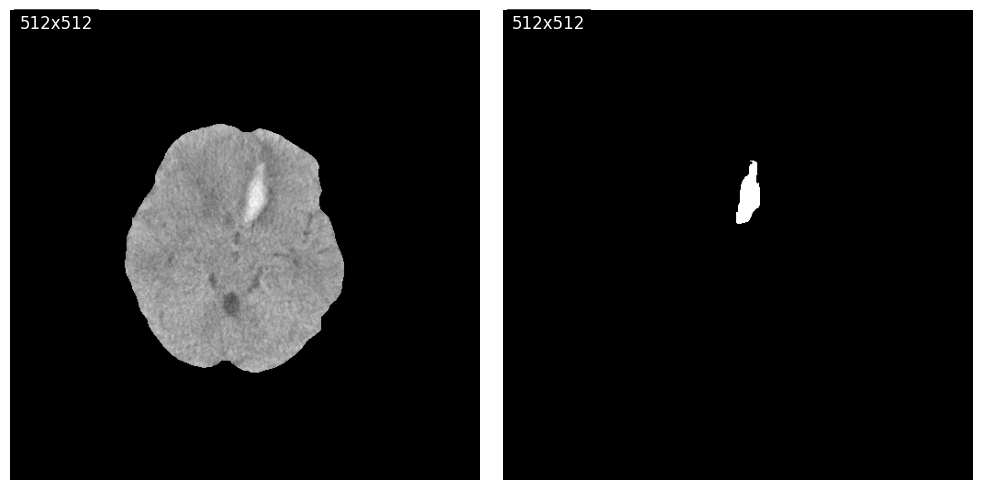

In [14]:
im, label = monai.utils.misc.first(loader)
print(im.shape, label.shape)
goster([im[0, 0],label[0, 0]])
# B   C  H    W
# 8  1  512  512

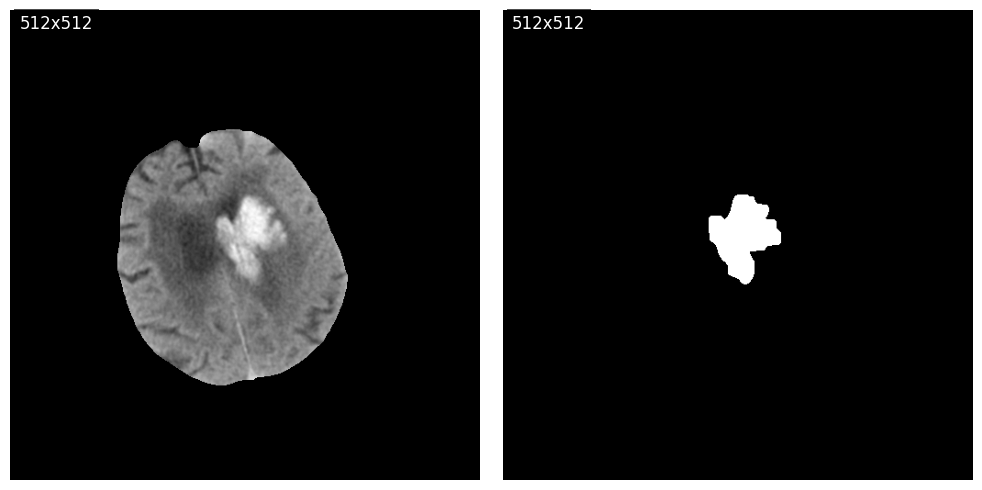

In [15]:
goster([im[2, 0],label[2, 0]])

# Veri Kümesinin Asıl Boyutunu Görüntüleme

In [16]:
print(f"Dataset Boyutu (Toplam Örnek Sayisi): {len(loader.dataset)}")

Dataset Boyutu (Toplam Örnek Sayisi): 2383


# Detaylı Boyut Analizi (Loader İçindeki Tüm Veriler)

In [17]:
# İlk batch'in boyutlarını alın
first_batch_im, first_batch_label = next(iter(loader))

# Boyutlara göre işlemleri yönetin
if len(first_batch_im.shape) == 5:
    B, C, D, H, W = first_batch_im.shape
    print(f"Veri 5D: Batch Boyutu = {B}, Kanal Sayisi = {C}, Derinlik = {D}, Yükseklik = {H}, Genişlik = {W}")
elif len(first_batch_im.shape) == 4:
    B, C, H, W = first_batch_im.shape
    print(f"Veri 4D: Batch Boyutu = {B}, Kanal Sayisi = {C}, Yükseklik = {H}, Genişlik = {W}")
else:
    print(f"Beklenmedik veri boyutu: {first_batch_im.shape}")

Veri 4D: Batch Boyutu = 8, Kanal Sayisi = 1, Yükseklik = 512, Genişlik = 512


# Eğitim, test ve doğrulama için 75-15-15 olarak veriyi böl

In [9]:
# Total number of samples
total_samples = len(ds)

# Calculate the number of samples for each set
train_size = int(0.75 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

# Generate indices for the full dataset and shuffle them
indices = list(range(total_samples))
np.random.seed(42)  # Set seed for reproducibility
np.random.shuffle(indices)

# Split indices into train, validation, and test
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

# Get the corresponding data for each set
train_images = [images[i] for i in train_indices]
train_labels = [labels[i] for i in train_indices]
val_images = [images[i] for i in val_indices]
val_labels = [labels[i] for i in val_indices]
test_images = [images[i] for i in test_indices]
test_labels = [labels[i] for i in test_indices]

# Create ArrayDatasets for each set
train_ds = ArrayDataset(train_images, data_transforms, train_labels, label_transforms)
val_ds = ArrayDataset(val_images, data_transforms, val_labels, label_transforms)
test_ds = ArrayDataset(test_images, data_transforms, test_labels, label_transforms)

# Create DataLoaders for each set
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=8, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=8, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=8, pin_memory=torch.cuda.is_available())

# Print the sizes
print(f"Training set size: {len(train_ds)} ({len(train_ds)/total_samples:.0%})")
print(f"Validation set size: {len(val_ds)} ({len(val_ds)/total_samples:.0%})")
print(f"Testing set size: {len(test_ds)} ({len(test_ds)/total_samples:.0%})")

Training set size: 1787 (75%)
Validation set size: 357 (15%)
Testing set size: 239 (10%)


# UNet Modelini Tanımla

In [10]:
from monai.networks.nets import AttentionUnet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUnet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
).to(device)


#  Kayıp Fonksiyonu, Optimizasyon ve Metrikler

In [11]:
from monai.losses import DiceLoss
from monai.losses import DiceCELoss

# loss_function = DiceLoss(sigmoid=True)
loss_function = DiceCELoss(to_onehot_y=False, sigmoid=True)


optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)

# Eğitime Başla

In [21]:
import torch
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau  # Learning rate scheduler ekledim

# Initialize tracking variables
epoch_loss_values = []
val_metric_values = []
best_metric = -1
best_metric_epoch = -1

# Number of epochs
num_epochs = 40

# Learning rate scheduler tanımla - ReduceLROnPlateau kullanıyorum
# Bu scheduler, validation performansı belirli bir sayıda epoch iyileşmediğinde
# learning rate'i düşürür
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-6)

# Training loop
for epoch in range(num_epochs):
    print("-" * 40)
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Current learning rate: {optimizer.param_groups[0]['lr']:.6f}")

    model.train()
    epoch_loss = 0
    step = 0

    # Create progress bar for training steps
    epoch_len = len(train_loader)  # Training loader size
    progress_bar = tqdm(train_loader, total=epoch_len, desc=f"Training", unit="batch")

    # Training steps
    for batch_data in progress_bar:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Update progress bar description with current loss
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    # Calculate average loss for epoch
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"Epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    # Validation phase - now runs every epoch
    model.eval()
    with torch.no_grad():
        dice_metric.reset()

        # Create progress bar for validation
        val_progress = tqdm(val_loader, desc=f"Validation", unit="batch")

        for val_data in val_progress:
            val_inputs, val_labels = val_data[0].to(device), val_data[1].to(device)
            val_outputs = model(val_inputs)
            val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
            dice_metric(y_pred=val_outputs, y=decollate_batch(val_labels))

        metric = dice_metric.aggregate().item()
        val_metric_values.append(metric)
        dice_metric.reset()

        # Learning rate scheduler adımı - validation metriği kullanarak rate'i günceller
        scheduler.step(metric)  # Burada scheduler'ı çağırıyoruz

        if metric > best_metric:
            best_metric = metric
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/model_best_2_yeni_tekrar_att.pth")
            print(f"✓ Saved new best model with dice metric: {metric:.4f}")

        print(f"Validation Results - Epoch: {epoch + 1}")
        print(f"Mean Dice: {metric:.4f} (Best: {best_metric:.4f} at epoch {best_metric_epoch})")

print("-" * 40)
print(f"Training completed!")
print(f"Best mean dice: {best_metric:.4f} at epoch: {best_metric_epoch}")

----------------------------------------
Epoch 1/40
Current learning rate: 0.000300


Training: 100%|██████████| 224/224 [02:59<00:00,  1.25batch/s, loss=1.2527]


Epoch 1 average loss: 1.4103


Validation: 100%|██████████| 45/45 [00:35<00:00,  1.27batch/s]


✓ Saved new best model with dice metric: 0.2545
Validation Results - Epoch: 1
Mean Dice: 0.2545 (Best: 0.2545 at epoch 1)
----------------------------------------
Epoch 2/40
Current learning rate: 0.000300


...

Validation Results - Epoch: 39
Mean Dice: 0.6767 (Best: 0.6865 at epoch 37)
----------------------------------------
Epoch 40/40
Current learning rate: 0.000075


Training: 100%|██████████| 224/224 [01:38<00:00,  2.28batch/s, loss=0.1525]


Epoch 40 average loss: 0.2417


Validation: 100%|██████████| 45/45 [00:15<00:00,  2.85batch/s]

Validation Results - Epoch: 40
Mean Dice: 0.6860 (Best: 0.6865 at epoch 37)
----------------------------------------
Training completed!
Best mean dice: 0.6865 at epoch: 37


# Eğitim, doğrulama ve test için ortalama dice hesaplanacak

In [13]:
from tqdm import tqdm

def evaluate_model(model, data_loader, device, post_process=None):
    """
    Evaluate a model on a dataset and return mean Dice score

    Args:
        model: The PyTorch model to evaluate
        data_loader: DataLoader containing the evaluation dataset
        device: Device to run evaluation on (CPU or GPU)
        post_process: Post-processing transforms for model output

    Returns:
        float: Mean Dice score
    """
    model.eval()
    dice_metric = DiceMetric(include_background=False, reduction="mean")

    with torch.no_grad():
        dice_metric.reset()
        progress_bar = tqdm(data_loader, desc="Evaluation", unit="batch")

        for batch_data in progress_bar:
            inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
            outputs = model(inputs)

            if post_process:
                outputs = [post_process(i) for i in decollate_batch(outputs)]
            else:
                outputs = decollate_batch(outputs)

            dice_metric(y_pred=outputs, y=decollate_batch(labels))

        mean_dice = dice_metric.aggregate().item()
        return mean_dice

# Load the best model
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/model_best_2_yeni_tekrar_att.pth"))

# Evaluate on all datasets
train_dice = evaluate_model(model, train_loader, device, post_trans)
val_dice = evaluate_model(model, val_loader, device, post_trans)
test_dice = evaluate_model(model, test_loader, device, post_trans)

print(f"Final Model Performance:")
print(f"Training Set Dice: {train_dice:.4f}")
print(f"Validation Set Dice: {val_dice:.4f}")
print(f"Test Set Dice: {test_dice:.4f}")

Evaluation: 100%|██████████| 30/30 [00:24<00:00,  1.23batch/s]

Final Model Performance:
Training Set Dice: 0.7917
Validation Set Dice: 0.6865
Test Set Dice: 0.6616


# 10 farklı test görselinde maske (yeşil) ve tahmin (kırmızı) görselleri üst üste çizilecek

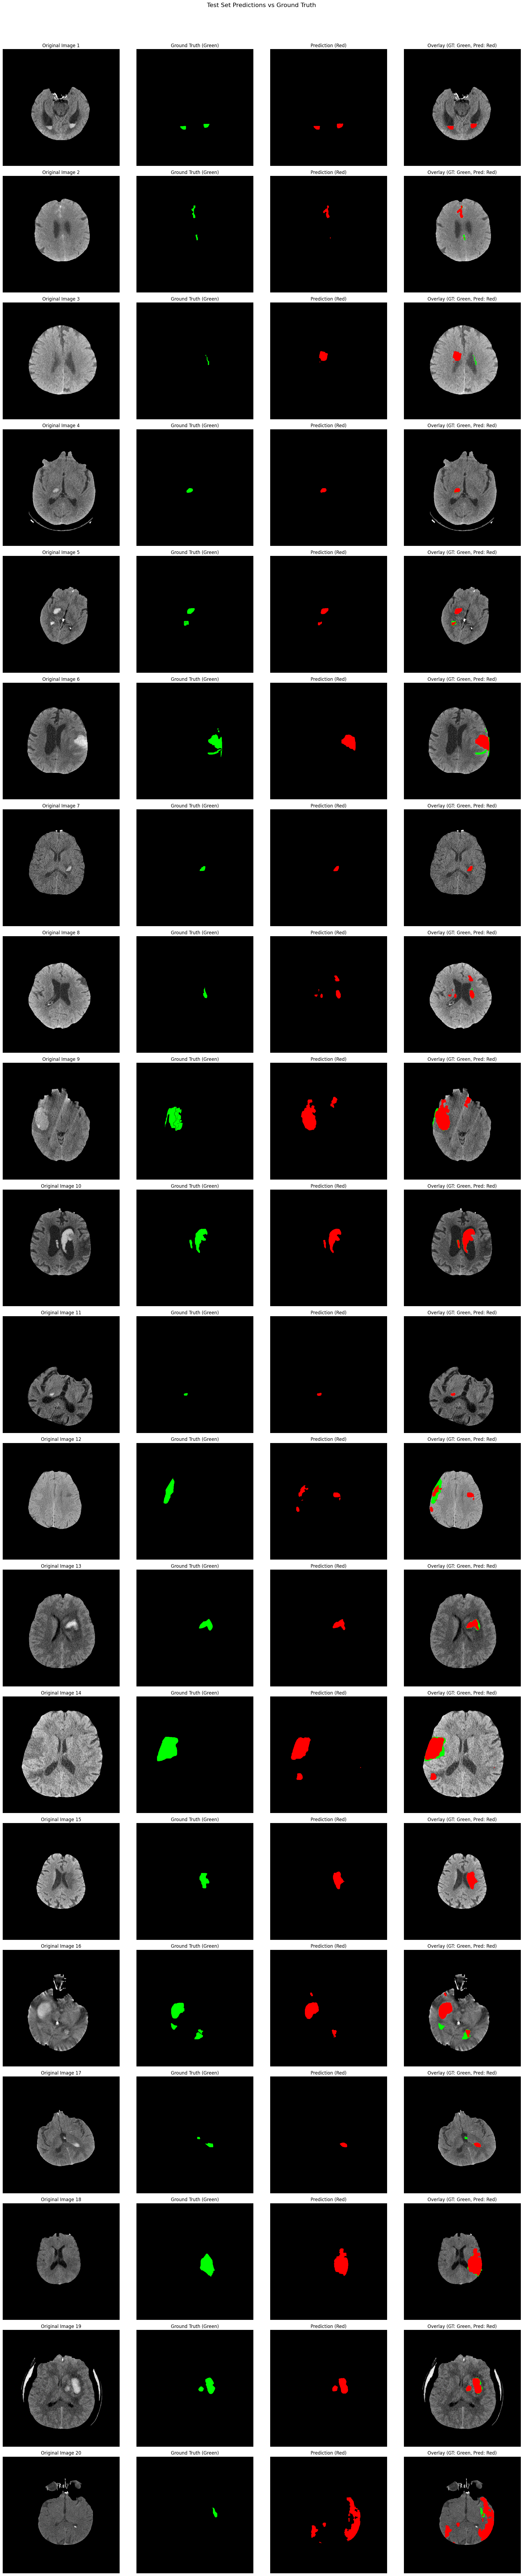

In [14]:
import torch
import numpy as np
from monai.transforms import ToNumpy

import matplotlib.pyplot as plt

# Ensure the best model is loaded and set to evaluation mode
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/Biyomedikal/6.Quiz/model_best_2_yeni_tekrar_att.pth"))
model.eval()

# Get 10 samples from the test loader
num_samples_to_show = 20
samples_shown = 0
fig, axes = plt.subplots(num_samples_to_show, 4, figsize=(20, 5 * num_samples_to_show))
fig.suptitle("Test Set Predictions vs Ground Truth", fontsize=16)

# Define a transform to convert tensors to numpy arrays for visualization
to_numpy = ToNumpy()

with torch.no_grad():
    for i, test_data in enumerate(test_loader):
        if samples_shown >= num_samples_to_show:
            break

        test_images, test_labels = test_data[0].to(device), test_data[1].to(device)
        pred_outputs = model(test_images)
        pred_outputs_processed = [post_trans(i) for i in decollate_batch(pred_outputs)]

        # Iterate through the batch
        for j in range(len(test_images)):
            if samples_shown >= num_samples_to_show:
                break

            # Get individual image, label, and prediction
            img = to_numpy(test_images[j][0]).astype(np.float32) # Original image (C=1, H, W) -> (H, W)
            label = to_numpy(test_labels[j][0]).astype(np.uint8) # Ground truth mask (C=1, H, W) -> (H, W)
            pred = to_numpy(pred_outputs_processed[j][0]).astype(np.uint8) # Prediction mask (C=1, H, W) -> (H, W)

            # Create RGB version of the original image for overlay
            overlay_img = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)

            # Apply green color for ground truth mask
            overlay_img[label == 1] = [0, 255, 0] # Green

            # Apply red color for prediction mask (overlaying green where they overlap)
            overlay_img[pred == 1] = [255, 0, 0] # Red

            # Plotting
            ax_row = axes[samples_shown]

            # Original Image
            ax_row[0].imshow(img, cmap='gray')
            ax_row[0].set_title(f"Original Image {samples_shown+1}")
            ax_row[0].axis('off')

            # Ground Truth Mask (Green)
            gt_viz = np.zeros_like(overlay_img)
            gt_viz[label == 1] = [0, 255, 0]
            ax_row[1].imshow(gt_viz)
            ax_row[1].set_title("Ground Truth (Green)")
            ax_row[1].axis('off')

            # Predicted Mask (Red)
            pred_viz = np.zeros_like(overlay_img)
            pred_viz[pred == 1] = [255, 0, 0]
            ax_row[2].imshow(pred_viz)
            ax_row[2].set_title("Prediction (Red)")
            ax_row[2].axis('off')

            # Overlay Image
            ax_row[3].imshow(overlay_img)
            ax_row[3].set_title("Overlay (GT: Green, Pred: Red)")
            ax_row[3].axis('off')

            samples_shown += 1

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to prevent title overlap
plt.show()

# Clean up variables if needed
del test_images, test_labels, pred_outputs, pred_outputs_processed, img, label, pred, overlay_img, gt_viz, pred_viz